#### Simple Linear Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
### Reading the Dataset
df = pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


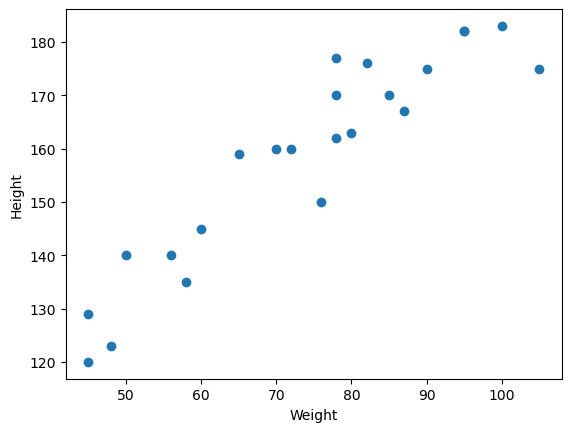

In [6]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
# Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [8]:
import seaborn as sns

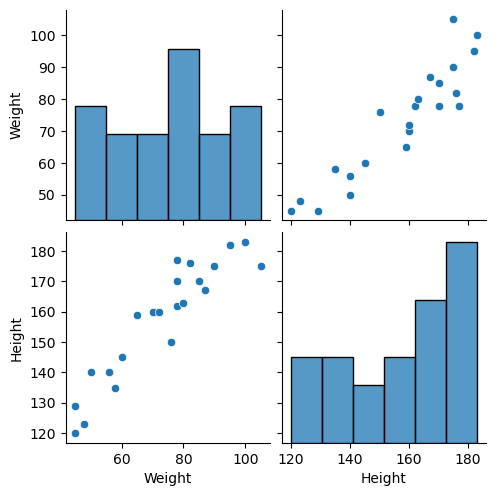

In [9]:
sns.pairplot(df)

In [14]:
#### Independent and Dependent Feature
# Weight is independent and height is dependent
X = df[['Weight']]  ### Independent Feature should be in Data Frame for training a model or 2D Array
Y = df['Height']  ### It should be as a series because we will have only one feature for prediction like price or height

#### Splitting the Data for Training and Testing

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,Y,test_size=0.2,random_state=42)

In [21]:
X_train.shape

(18, 1)

#### Standardization

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
X_train=scaler.fit_transform(X_train)

In [25]:
X_test=scaler.fit_transform(X_test)

#### Applying Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

In [28]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
### Slope  & Intercept
print(f"Slope or Cooefficient {regression.coef_}") ## One unit is leading towards the 17.03 up in the graph
print(f"Intercept {regression.intercept_}") ### When your weight value is zero its meeting the y-axis 157.5

Slope or Cooefficient [17.03440872]
Intercept 157.5


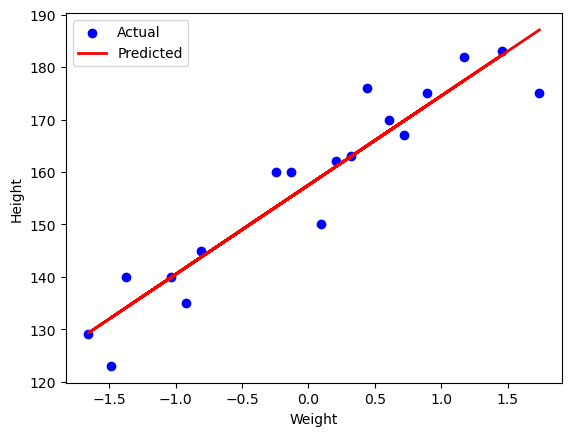

In [36]:
### Plotting the best fit line
plt.scatter(X_train, y_train, color='blue', label='Actual')
plt.plot(X_train, regression.predict(X_train), color='red', linewidth=2, label='Predicted')
plt.legend()
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

#### Prediction

In [37]:
## Prediction for y
y_pred=regression.predict(X_test)

#### Performance Metrics

In [41]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)

In [46]:
print(f" Root Mean Square Error: {rmse}\n Mean Square Error:{mse}\n Mean Absolute Error: {mae}")

 Root Mean Square Error: 8.931298370244372
 Mean Square Error:79.76809057832979
 Mean Absolute Error: 7.9393285483063725


#### R Square and Adjusted R Square

In [48]:
from sklearn.metrics import r2_score 

In [49]:
score=r2_score(y_test,y_pred)
print(score)

0.8379487839705635


In [52]:
regression.predict(scaler.transform([[82]]))

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([167.55281068])